In [1]:
from rdkit import Chem, DataStructs
from rdkit.Chem.Fraggle import FraggleSim
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdmolops
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from rdkit.Chem import rdDepictor
from rdkit import RDConfig
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Geometry import Point3D
from rdkit.Chem import rdForceFieldHelpers
from rdkit.Chem import rdMolDescriptors
from random import randrange
import py3Dmol
import copy
import numpy as np
import matplotlib.pyplot as plt

#from rdkit import rdBase
#rdBase.DisableLog('rdApp.error')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

import os


In [2]:
def Get_data_averages(folder):
    DGs_best = [[] *i for i in range(51)]
    LogPs_best = [[] *i for i in range(51)]
    SAs_best = [[] *i for i in range(51)]
    pKas_best = [[] *i for i in range(51)]
    smiles_gen = [[] *i for i in range(51)]
    scores_best = [[] *i for i in range(51)]
    smiles_gens = [[] *i for i in range(51)]
    smiles_gens = [[] *i for i in range(51)]
    top_performings = [[0] * 51 ,[0] * 51 ,[0] * 51 ]
    average_cover = []
    top100_smiles = []

    #Reading the top100 of best performing DBA tweezers for coverage calculation.
    pathfile_top100 = "top_100_best_performings.out"
    #print(pathfile_top100)
    with open(pathfile_top100, "r+") as file:
        # Reading from a file
        for line in file:    
            data = line.split()
            smile = data[-1]
            top100_smiles.append(smile)
    
    for runfile in range(1,4):
    #print(runfile)
        pathfile = str(folder) + "/GB-GA_generations_run-" + str(runfile) +".out"
        Generation = 0
        with open(pathfile, "r+") as file1:
            # Reading from a file
            content = [line.strip() for line in file1]
            smiles_tmp = []
            for i,row in enumerate(content):
                #print(row)
                if 'idx' in row:
                    #for line in range(i+2,i+34):
                    data = content[i+2].split()
                    #print(data)
                    scores_best[Generation].append(float(data[3]))
                    DGs_best[Generation].append(float(data[4]))
                    LogPs_best[Generation].append(float(data[5]))
                    pKas_best[Generation].append(float(data[6]))
                    SAs_best[Generation].append(float(data[7]))
                    top_smiles = 0
                    for line in range(i+2,i+34):
                        data_tmp = content[line].split()
                        #print(data_tmp[8])
                        #smiles_tmp.append(str(data_tmp[8]))
                        smiles_gens[Generation].append(str(data_tmp[8]))
                        if str(data_tmp[8]) in top100_smiles:
                            top_smiles += 1
                            #print("top performing found",top_smiles)
                    #smiles_gens[Generation].append(smiles_tmp)
                    top_performings[runfile-1][Generation] = top_smiles + top_performings[runfile-1][Generation]
                    #print(Generation,top_performings[runfile-1][Generation])
                    Generation += 1
            #print(smiles_gens)
            if Generation < 50:
                while Generation <= 50:
                    scores_best[Generation].append(scores_best[Generation-1][runfile-1])
                    DGs_best[Generation].append(DGs_best[Generation-1][runfile-1])
                    LogPs_best[Generation].append(LogPs_best[Generation-1][runfile-1])
                    pKas_best[Generation].append(pKas_best[Generation-1][runfile-1])
                    SAs_best[Generation].append(SAs_best[Generation-1][runfile-1])
                    smiles_gens[Generation].append(smiles_gens[Generation-1][runfile-1])
                    top_performings[runfile-1][Generation] = top_performings[runfile-1][Generation-1]
                    #print(Generation,top_performings[runfile-1][Generation])
                    Generation += 1
                
    DGs_means = []
    LogPs_means = []
    SAs_means = []
    pKas_means = []
    scores_means = []
    for i in range(51):
        DGs_means.append(np.median(np.array(DGs_best[i][:])))
        LogPs_means.append(np.median(np.array(LogPs_best[i][:])))
        SAs_means.append(np.median(np.array(SAs_best[i][:])))
        pKas_means.append(np.median(np.array(pKas_best[i][:])))
        scores_means.append(np.median(np.array(scores_best[i][:])))
        average_cover.append(np.median([top_performings[0][i],top_performings[1][i],top_performings[2][i]]))
    return scores_means, DGs_means, LogPs_means, pKas_means, SAs_means, smiles_gens, average_cover

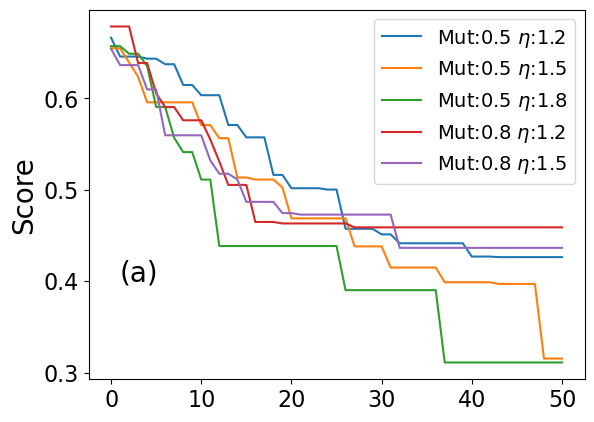

In [3]:
#fig, ax = plt.subplots()
#ax.errorbar(scores_means, scores_std, xerr=0.2, yerr=0.4)
scores_params1, DGs_params1, LogPs_params1, pKas_params1, SAs_params1, smiles_params1, cover_params1 = Get_data_averages("params1")
scores_params2, DGs_params2, LogPs_params2, pKas_params2, SAs_params2, smiles_params2, cover_params2 = Get_data_averages("params2")
scores_params3, DGs_params3, LogPs_params3, pKas_params3, SAs_params3, smiles_params3, cover_params3 = Get_data_averages("params3")
scores_params4, DGs_params4, LogPs_params4, pKas_params4, SAs_params4, smiles_params4, cover_params4 = Get_data_averages("params4")
scores_params5, DGs_params5, LogPs_params5, pKas_params5, SAs_params5, smiles_params5, cover_params5 = Get_data_averages("params5")
fig, ax = plt.subplots()
#ax.plot(scores_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(scores_params2,label="Mut:0.8 SP:1.5")
#ax.plot(scores_params3,label="Mut:0.8 SP:1.2")
#ax.plot(scores_params4,label="Mut:0.5 SP:1.2")
#ax.plot(scores_params5,label="Mut:0.5 SP:1.8")
ax.plot(scores_params4,label=r'Mut:0.5 $\eta$:1.2') # plotting by columns
ax.plot(scores_params1,label=r'Mut:0.5 $\eta$:1.5')
ax.plot(scores_params5,label=r'Mut:0.5 $\eta$:1.8')
ax.plot(scores_params3,label=r'Mut:0.8 $\eta$:1.2')
ax.plot(scores_params2,label=r'Mut:0.8 $\eta$:1.5')
#ax.set_xlabel("Generation",fontsize=20)
ax.set(xlabel=None)
ax.set_ylabel("Score",fontsize=20)
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(fontsize=14)
plt.text(1, 0.4, '(a)', fontsize = 20)
plt.savefig("scores.png",bbox_inches='tight')
plt.show()

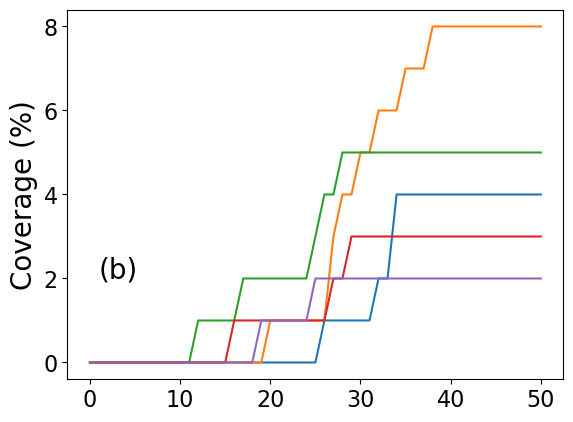

In [4]:
fig, ax = plt.subplots()
#ax.plot(DGs_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(DGs_params2,label="Mut:0.8 SP:1.5")
#ax.plot(DGs_params3,label="Mut:0.8 SP:1.2")
#ax.plot(DGs_params4,label="Mut:0.5 SP:1.2")
#ax.plot(DGs_params5,label="Mut:0.5 SP:1.8")
ax.plot(cover_params4,label="Mut:0.5 SP:1.2") # plotting by columns
ax.plot(cover_params1,label="Mut:0.5 SP:1.5")
ax.plot(cover_params5,label="Mut:0.5 SP:1.8")
ax.plot(cover_params3,label="Mut:0.8 SP:1.2")
ax.plot(cover_params2,label="Mut:0.8 SP:1.5")
#ax.set_xlabel("Generation",fontsize=20)
ax.set(xlabel=None)
ax.set_ylabel("Score",fontsize=20)
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#ax.legend(fontsize=14)
ax.set_ylabel("Coverage (%)")
plt.text(1, 2, '(b)', fontsize = 20)
plt.savefig("cover.png",bbox_inches='tight')
plt.show()

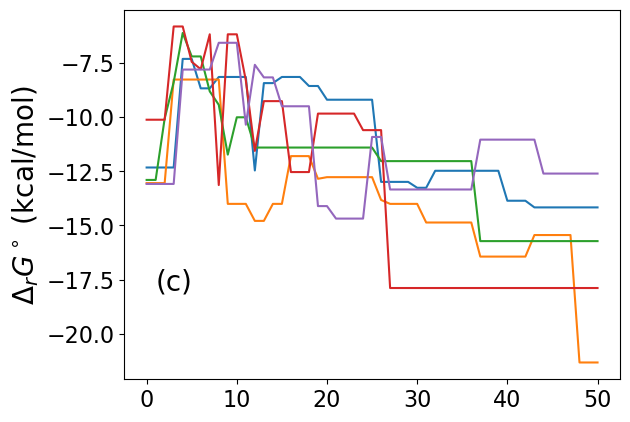

In [5]:
#DGs_params5=[]
fig, ax = plt.subplots()
#ax.plot(DGs_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(DGs_params2,label="Mut:0.8 SP:1.5")
#ax.plot(DGs_params3,label="Mut:0.8 SP:1.2")
#ax.plot(DGs_params4,label="Mut:0.5 SP:1.2")
#ax.plot(DGs_params5,label="Mut:0.5 SP:1.8")
ax.plot(DGs_params4,label="Mut:0.5 SP:1.2") # plotting by columns
ax.plot(DGs_params1,label="Mut:0.5 SP:1.5")
ax.plot(DGs_params5,label="Mut:0.5 SP:1.8")
ax.plot(DGs_params3,label="Mut:0.8 SP:1.2")
ax.plot(DGs_params2,label="Mut:0.8 SP:1.5")
#ax.set_xlabel("Generation",fontsize=20)
ax.set(xlabel=None)
ax.set_ylabel("Score",fontsize=20)
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#ax.legend(fontsize=14)
ax.set_ylabel("$\Delta_r G^\circ$ (kcal/mol)")
plt.text(1, -18, '(c)', fontsize = 20)
plt.savefig("DGs.png",bbox_inches='tight')
plt.show()

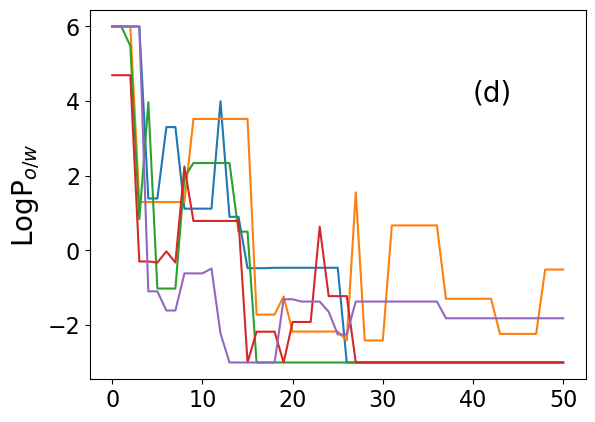

In [6]:
#LogPs_params5=[]
fig, ax = plt.subplots()
#ax.plot(LogPs_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(LogPs_params2,label="Mut:0.8 SP:1.5")
#ax.plot(LogPs_params3,label="Mut:0.8 SP:1.2")
#ax.plot(LogPs_params4,label="Mut:0.5 SP:1.2")
#ax.plot(LogPs_params5,label="Mut:0.5 SP:1.8")
ax.plot(LogPs_params4,label="Mut:0.5 SP:1.2") # plotting by columns
ax.plot(LogPs_params1,label="Mut:0.5 SP:1.5")
ax.plot(LogPs_params5,label="Mut:0.5 SP:1.8")
ax.plot(LogPs_params3,label="Mut:0.8 SP:1.2")
ax.plot(LogPs_params2,label="Mut:0.8 SP:1.5")
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#ax.legend(fontsize=14)
#ax.set_xlabel("Generation",fontsize=20)
ax.set(xlabel=None)
ax.set_ylabel("LogP$_{o/w}$",fontsize=20)
plt.text(40, 4, '(d)', fontsize = 20)
plt.savefig("LogPs.png",bbox_inches='tight')
plt.show()

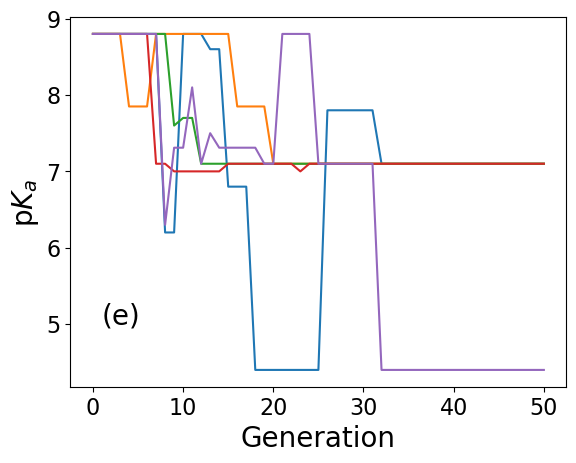

In [7]:
#pKas_params5=[]
fig, ax = plt.subplots()
#ax.plot(pKas_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(pKas_params2,label="Mut:0.8 SP:1.5")
#ax.plot(pKas_params3,label="Mut:0.8 SP:1.2")
#ax.plot(pKas_params4,label="Mut:0.5 SP:1.2")
#ax.plot(pKas_params5,label="Mut:0.5 SP:1.8")
ax.plot(pKas_params4,label="Mut:0.5 SP:1.2") # plotting by columns
ax.plot(pKas_params1,label="Mut:0.5 SP:1.5")
ax.plot(pKas_params5,label="Mut:0.5 SP:1.8")
ax.plot(pKas_params3,label="Mut:0.8 SP:1.2")
ax.plot(pKas_params2,label="Mut:0.8 SP:1.5")
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#ax.legend(fontsize=14)
ax.set_xlabel("Generation",fontsize=20)
#ax.set(xlabel=None)
ax.set_ylabel("p$K_a$",fontsize=20)
plt.text(1, 5, '(e)', fontsize = 20)
plt.savefig("pKas.png",bbox_inches='tight')
plt.show()

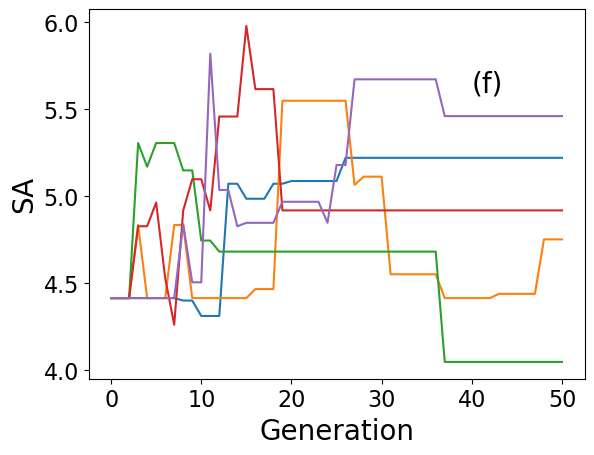

In [8]:
#SAs_params5=[]
fig, ax = plt.subplots()
#ax.plot(SAs_params1,label="Mut:0.5 SP:1.5") # plotting by columns
#ax.plot(SAs_params2,label="Mut:0.8 SP:1.5")
#ax.plot(SAs_params3,label="Mut:0.8 SP:1.2")
#ax.plot(SAs_params4,label="Mut:0.5 SP:1.2")
#ax.plot(SAs_params5,label="Mut:0.5 SP:1.8")
ax.plot(SAs_params4,label="Mut:0.5 SP:1.2") # plotting by columns
ax.plot(SAs_params1,label="Mut:0.5 SP:1.5")
ax.plot(SAs_params5,label="Mut:0.5 SP:1.8")
ax.plot(SAs_params3,label="Mut:0.8 SP:1.2")
ax.plot(SAs_params2,label="Mut:0.8 SP:1.5")
#ax.set_xticklabels('x',fontsize=18)
#ax.set_yticklabels('y',fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
#ax.legend(fontsize=14)
ax.set_xlabel("Generation",fontsize=20)
#ax.set(xlabel=None)
ax.set_ylabel("SA",fontsize=20)
plt.text(40, 5.6, '(f)', fontsize = 20)
plt.savefig("SAs.png",bbox_inches='tight')
plt.show()

In [9]:
import re
import sys
#Function to filtrate the list of molecules in the last generation given some properties
def Get_data_last_Gen(genfile):
    DGs = []
    LogPs = []
    SAs = []
    pKas = []
    smiles_gen = []
    scores = []
    smiles = []

    file = open(genfile, "r+") 

    for i,line in enumerate(file):
        if re.search("idx",line):
            temp = i
            
    line_last_idx= temp
    file = open(genfile, "r+") 
    for i,line in enumerate(file):
        if i > line_last_idx+1:
            data = line.split()
            smile = data[8]
            mol = Chem.MolFromSmiles(smile)
            if Descriptors.NumRotatableBonds(mol) < 6 and len(Chem.FindMolChiralCenters(mol)) == 0 and float(data[6]) < 7.4 and float(data[5]) < 3.0:
                #print(Descriptors.NumRotatableBonds(mol), Lipinski.NumRotatableBonds(mol), rdMolDescriptors.CalcNumRotatableBonds(mol), rdMolDescriptors.CalcNumRotatableBonds(mol, strict=True))
                #print(smiles,Descriptors.NumRotatableBonds(mol), rdMolDescriptors.CalcNumRotatableBonds(mol), rdMolDescriptors.CalcNumRotatableBonds(mol, strict=True))
                print(data[0],data[1],data[4],data[5],data[6],data[7],smile,Descriptors.NumRotatableBonds(mol))
                smiles.append(smile)
        if i == line_last_idx+33:
            break
            
    return smiles

params1 Run file: 1
(48, 6) -23.203 -0.51022 7.1 4.75088 [98*]c1c(F)cc(F)c2c1CC1=C(CNC3=C1CC(c1cc([99*])ccc1S(C)(=O)=O)=CC3)C2N 2
(43, 1) -15.4446 -2.2352 7.1 4.43769 [98*]c1c(F)c(C=O)cc2c1CC1=C(CNC3=C1CC(c1cc([99*])ccc1S(C)(=O)=O)=C(C#N)C3)C2 3
(37, 2) -16.4382 -1.29389 7.1 4.25329 [98*]c1c(F)cc(F)c2c1CC1=C(CNC3=C1CC(c1cc([99*])ccc1S(C)(=O)=O)=CC3)C2 2
(31, 13) -14.8665 0.671077 4.4 4.55024 [98*]c1c2c(cc[n+]1CC(F)(F)F)CC1=C(C2)C2=C(CC=C(c3cc([99*])cnc3C(=O)O)C2)C1 3
(50, 0) -12.7296 -2.79673 7.1 4.49559 [98*]c1c(F)c(C=O)c(C(=O)[O-])c2c1CC1=C(CNC3=C1CC(c1cc([99*])ccc1S(C)(=O)=O)=C(C#N)C3)C2 4
(42, 4) -15.1218 -1.11301 7.1 4.74826 [98*]c1c(F)c(C=O)cc2c1C(OC)c1c(cnc3c1CC(c1cc([99*])ccc1S(C)(=O)=O)=C(C#N)C3)C2 4
(26, 12) -13.8274 -2.40936 7.1 5.56802 [98*]c1c(C(F)(F)F)ccc2c1CC1C3=C(CC(C(=O)O[O-])=C(c4cc([99*])ccc4S(C)(=O)=O)C3)OC21 3
(36, 13) -13.6255 -1.33277 7.1 4.13934 [98*]c1c(F)ccc2c1CC1=C(CNC3=C1CC(c1cc([99*])ccc1S(C)(=O)=O)=CC3)C2 2
(32, 10) -13.0904 -3 7.1 6.05676 [98*]c1c(C(F)(F)

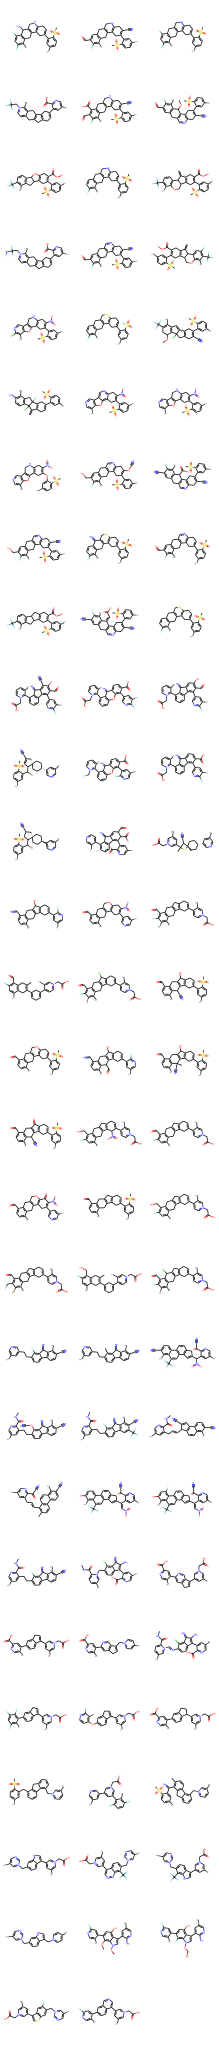

In [10]:
tmp_smiles = []
mols_list = []
totmols = 0
for params in ['params1','params2','params3','params4','params5']:
#for params in ['params5']:
    for i in [1,2,3]:
        print(params,"Run file:",i)
        smiles_fromruns = Get_data_last_Gen(params + "/GB-GA_generations_run-" + str(i) +".out")
        #print(len(smiles_fromruns))        
        mol_list = [Chem.MolFromSmiles(s) for s in smiles_fromruns]
        totmols += len(smiles_fromruns)
        for mol in mol_list:
            mols_list.append(mol)

#smiles = np.array(tmp_smiles).reshape(-1)
print(len(mols_list))
#mol_list = [Chem.MolFromSmiles(s) for s in smiles]
Draw.MolsToGridImage(mols_list,maxMols=90,useSVG=True)

In [22]:
import re
import sys
#Function to get the molecules and properties for a given generation of tweezers
def Get_data_Gen(genfile,gen):
    DGs = []
    LogPs = []
    SAs = []
    pKas = []
    smiles_gen = []
    scores = []
    smiles = []
    ids = []
    idx_count = 0

    file = open(genfile, "r+") 

    for i,line in enumerate(file):
        if re.search("idx",line):
            if idx_count == gen:
                temp = i
            idx_count += 1
            
    line_last_idx = temp
    file = open(genfile, "r+") 
    for i,line in enumerate(file):
        if i > line_last_idx+1:
            data = line.split()
            id = str(data[0]) + " " + str(data[1])
            ids.append(id)
            scores.append(data[3])
            DGs.append(data[4])
            LogPs.append(data[5])
            pKas.append(data[6])
            SAs.append(data[7])
            smiles.append(data[8])
        if i == line_last_idx+33:
            break
            
    return ids, scores, DGs, LogPs, pKas, SAs, smiles

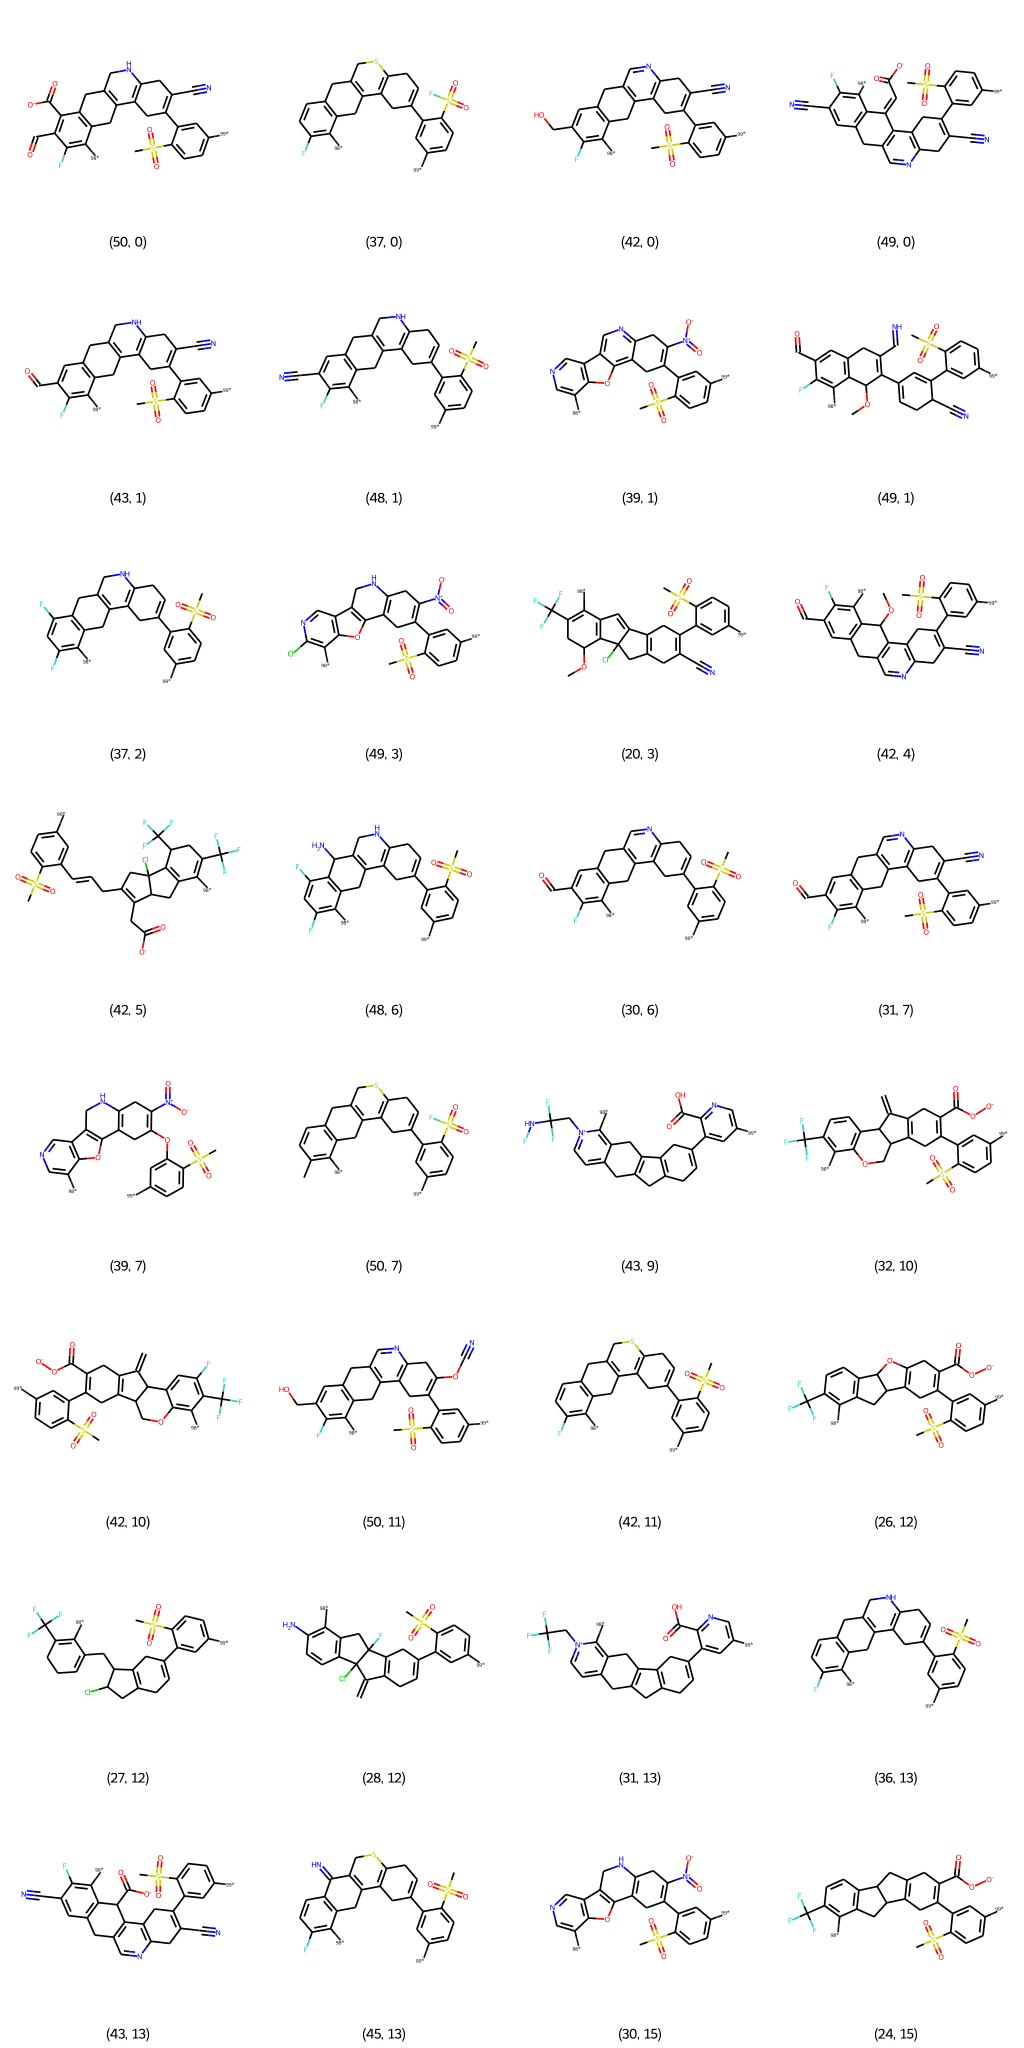

In [39]:
ids, scores, DGs, LogPs, pKas, SAs, smiles = Get_data_Gen('params1' + "/GB-GA_generations_run-" + "1" +".out",50)

mols_list = [Chem.MolFromSmiles(s) for s in smiles]
totmols += len(mols_list)

labels = []
for id in ids:
    gen, label = id.split()
    labels.append(re.sub('[)]', '', label))

data_mols = []
for i,mol in enumerate(mols_list):
    data_mols.append((int(labels[i]),mol,ids[i]))

#Sorting the molecules according the label
def fun(val):
    return val[0]

data_mols.sort(key=fun)
mols_sorted = []
ids_sorted = []
for data in data_mols:
    mols_sorted.append(data[1])
    ids_sorted.append(data[2])
    
#smiles = np.array(tmp_smiles).reshape(-1)
#mol_list = [Chem.MolFromSmiles(s) for s in smiles]
Draw.MolsToGridImage(mols_sorted,maxMols=90,molsPerRow=4,subImgSize=(300,300),legends=ids_sorted,returnPNG=False,useSVG=True)
#print(img.data)

In [ ]:
with open("smiles", "r+") as file1:
    # Reading from a file
    smiles = [line.rstrip() for line in file1]
    #print(len(smiles))
    for smile in smiles:
        mol1 = Chem.MolFromSmiles(smile)
        if Chem.GetFormalCharge(mol1) != 0:
            neutral_smiles1 = neutralize_smiles([Chem.MolToSmiles(mol1)])
            mol2 = Chem.MolFromSmiles(neutral_smiles1[0])
            if Chem.GetFormalCharge(mol2) != 0:
                rings = mol2.GetRingInfo().AtomRings()
                rings_info = mol2.GetRingInfo()
                B_smarts = Chem.MolFromSmarts("[#5-]")
                N_smarts = Chem.MolFromSmarts("[#7R1+]")
                N_matchs = mol2.GetSubstructMatches(N_smarts)
                BC_pairs = []
                B_matches = []
                for B_match in mol2.GetSubstructMatches(B_smarts):
                    B_atom = mol2.GetAtomWithIdx(B_match[0])
                    B_matches.append(B_match[0])
                    for neigh in B_atom.GetNeighbors():
                        if neigh.GetAtomicNum() == 6:
                            BC_pairs.append([B_match[0],neigh.GetIdx()])
                BExclude = []
                for BC_pair in BC_pairs:
                    for N_match in N_matchs:
                        if rings_info.AreAtomsInSameRing(BC_pair[1],N_match[0]):
                            BExclude.append(BC_pair[0])
                BO_groups = []
                B_matches.sort(reverse=True)
                for B_match in B_matches:
                    if B_match not in BExclude:
                        B_atom = mol2.GetAtomWithIdx(B_match)
                        O_atoms = []
                        for neigh in B_atom.GetNeighbors():
                            if neigh.GetAtomicNum() == 8:
                                O_atoms.append(neigh.GetIdx())
                        O_atoms.sort(reverse=True)
                        BO_groups.append(O_atoms)
                        
                em = Chem.RWMol(mol2)
                em.BeginBatchEdit()
                i = 0
                for B_match in B_matches:
                    if B_match not in BExclude:
                        Batom = em.GetAtomWithIdx(B_match)
                        Batom.SetFormalCharge(0)
                        em.RemoveAtom(BO_groups[i][0])
                        i += 1
                em.CommitBatchEdit()
                mol3 = em.GetMol()
                if Chem.GetFormalCharge(mol3) != 0:
                    while Chem.GetFormalCharge(mol3) != 0:
                        Cl_anion = Chem.MolFromSmiles("[Cl-]")
                        Na_cation = Chem.MolFromSmiles("[Na+]")
                        if Chem.GetFormalCharge(mol3) < 0:
                            molfrag = Chem.CombineMols(mol3,Na_cation)
                        elif Chem.GetFormalCharge(mol3) > 0:
                            molfrag = Chem.CombineMols(mol3,Cl_anion)
                        mol3 = copy.deepcopy(molfrag)
                    print("Returning neutral mol by adding counter anions",Chem.MolToSmiles(mol3))
                else:
                    print("Returning neutral mol mol3")
            else:
                print("Returning neutral mol mol2")       
        else:
            print("Returning neutral mol mol1")

In [6]:
!jupyter nbconvert --to script Neutralization_workflow.ipynb

[NbConvertApp] Converting notebook Neutralization_workflow.ipynb to script
/users/glara/anaconda3/envs/rdkit-env/lib/python3.10/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
[NbConvertApp] Writing 5189 bytes to Neutralization_workflow.py
